In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy.linalg as nl
import scipy.stats as ss
from sklearn.decomposition import PCA

In [52]:
df = pd.read_excel('питон 3.xlsx', index_col=0)
X = df.values
y = df.columns.tolist()
f_len = len(y)

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
df = pd.DataFrame(X, index=df.index,
                  columns=df.columns)
print(df)

                                                X1        X2        X3  \
Регион                                                                   
Алтайский край                            0.619734 -0.548015 -0.775311   
Амурская область                          0.252046  0.192832  0.459257   
Архангельская область без автономного ок -0.434304  0.272575  0.773213   
Астраханская область                      0.301071 -0.541205 -0.606368   
Белгородская область                     -1.267729 -0.092930 -0.036070   
...                                            ...       ...       ...   
Чеченская Республика                      1.624746 -0.569496 -1.065030   
Чувашская Республика — Чувашия            0.546196 -0.644783 -0.991702   
Чукотский автономный округ               -1.365779  4.519754  0.984161   
Ямало-Ненецкий автономный округ          -1.757979  3.790971  2.115514   
Ярославская область                      -0.679429 -0.117017 -0.151608   

                                     

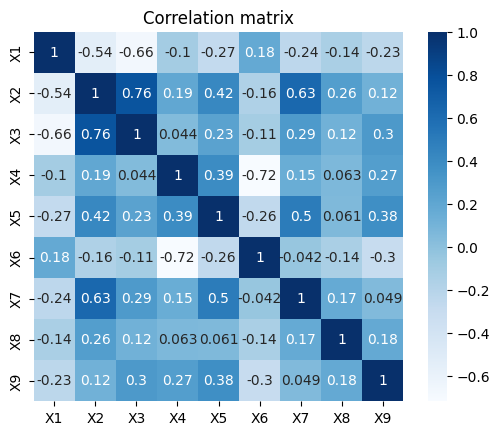

In [39]:
# Корреляционная матрица
corr = df.corr()
sns.heatmap(corr, vmax=1, square=True,
            annot=True, cmap="Blues")
plt.title("Correlation matrix")
plt.show()

In [40]:
# Проверим гипотезу о значимости корр. матрицы
eigvals, eigvecs = nl.eig(corr)
couple_list = []
for i in range(len(eigvals)):
    couple_list.append((eigvals[i], eigvecs[:, i]))

from operator import itemgetter
couple_list = sorted(couple_list, key=itemgetter(0), reverse=True)
eigvals_sorted = sorted(eigvals, reverse=True)

import math
def chi_2(n, k, R):  # Определим вспомогательную функцию
    return -(n - (1 / 6) * (2 * k + 5)) * math.log(nl.det(R), math.e)

chi_2_observed = chi_2(X.shape[0], X.shape[1], corr)
df = X.shape[1] * (X.shape[1] - 1) // 2

alpha = 0.05
chi_2_1 = ss.chi2.ppf(alpha / 2, df)
chi_2_2 = ss.chi2.ppf(1 - alpha / 2, df)

p_value = ss.chi2.sf(chi_2_observed, df)

print(f"Хи-квадрат наблюдаемое: {chi_2_observed:.4f}")
print(f"Хи-квадрат критическое 1: {chi_2_1:.4f}")
print(f"Хи-квадрат критическое 2: {chi_2_2:.4f}")
if chi_2_2 <= chi_2_observed:
    print("Отклоняем гипотезу H0\nМатрица парных коэффициентов корреляции значима")
else:
    print("Принимаем гипотезу H0\nМатрица парных коэффициентов корреляции незначима")

Хи-квадрат наблюдаемое: 324.5116
Хи-квадрат критическое 1: 21.3359
Хи-квадрат критическое 2: 54.4373
Отклоняем гипотезу H0
Матрица парных коэффициентов корреляции значима


In [43]:
def eigenval_left(l, n):
    return l / (1 + ss.norm.ppf(0.975) * math.sqrt(2 / (n - 1)))
# Функция для правой границы
def eigenval_right(l, n):
    return l / (1 - ss.norm.ppf(0.975) * math.sqrt(2 / (n - 1)))
intervals = np.empty((f_len, 3))
for i in range(intervals.shape[0]):
    intervals[i, 0] = eigenval_left(eigvals_sorted[i], X.shape[0])
    intervals[i, 1] = eigvals_sorted[i]
    intervals[i, 2] = eigenval_right(eigvals_sorted[i], X.shape[0])

pd_intervals = pd.DataFrame(
    intervals,
    columns=['Нижняя граница', 'Собственное значение', 'Верхняя граница'])
print(pd_intervals)

   Нижняя граница  Собственное значение  Верхняя граница
0        2.517852              3.279324         4.701061
1        1.307130              1.702444         2.440531
2        0.831487              1.082953         1.552463
3        0.742055              0.966474         1.385485
4        0.653176              0.850716         1.219540
5        0.337777              0.439931         0.630661
6        0.249019              0.324330         0.464942
7        0.192392              0.250576         0.359213
8        0.079276              0.103252         0.148016


In [44]:
# Проверка кратности собственных чисел
for i in range(f_len):
    for j in range(i + 1, f_len):
        condition1 = intervals[i, 0] <= intervals[j, 1] <= intervals[i, 2]
        condition2 = intervals[j, 0] <= intervals[i, 1] <= intervals[j, 2]

        if condition1 and condition2:
            print(f"λ{i+1} и λ{j+1} - кратные")
        elif condition1 or condition2:
            print(f"λ{i+1} и λ{j+1} - частичное пересечение")

λ3 и λ4 - кратные
λ3 и λ5 - кратные
λ4 и λ5 - кратные
λ6 и λ7 - частичное пересечение
λ7 и λ8 - кратные


In [45]:
total_variance = sum(eigvals_sorted)
cumulative_variance = 0

for i in range(len(eigvals_sorted)):
    cumulative_variance += eigvals_sorted[i]
    info_percent = cumulative_variance * 100 / total_variance
    print(f"Первые {i+1} компонент: {info_percent:.2f}%")

Первые 1 компонент: 36.44%
Первые 2 компонент: 55.35%
Первые 3 компонент: 67.39%
Первые 4 компонент: 78.12%
Первые 5 компонент: 87.58%
Первые 6 компонент: 92.46%
Первые 7 компонент: 96.07%
Первые 8 компонент: 98.85%
Первые 9 компонент: 100.00%


In [46]:
# Критерий Кайзера
eigvals_array = np.array(eigvals_sorted)
eigvals_gt_1 = eigvals_array[eigvals_array > 1]
print(f"Количество собственных значений > 1: {len(eigvals_gt_1)}")

print(f"Рекомендуемое количество компонент по критерию Кайзера: {len(eigvals_gt_1)}")

Количество собственных значений > 1: 3
Рекомендуемое количество компонент по критерию Кайзера: 3


 Eigenvalue  % Total Variance  Cumulative Eigenvalue  Cumulative %
   3.279324             36.44                 3.2793         36.44
   1.702444             18.92                 4.9818         55.36
   1.082953             12.03                 6.0647         67.39
   0.966474             10.74                 7.0312         78.13
   0.850716              9.45                 7.8819         87.58
   0.439931              4.89                 8.3218         92.47
   0.324330              3.60                 8.6462         96.07
   0.250576              2.78                 8.8967         98.85
   0.103252              1.15                 9.0000        100.00


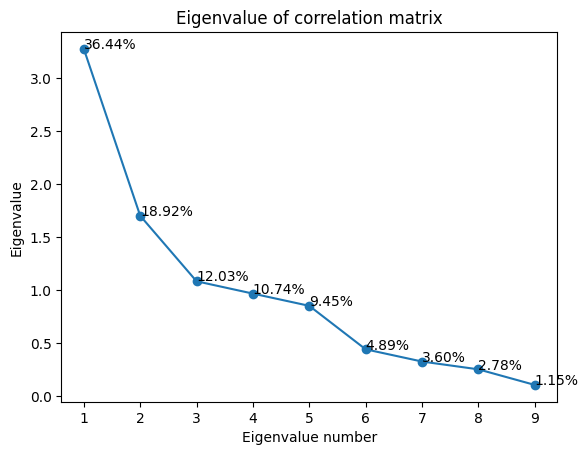

In [47]:
sum_lmbd = eigvals.sum()
dft = pd.DataFrame([])
dft['Component'] = list(range(1, f_len + 1))
dft['Eigenvalue'] = eigvals_sorted
dft['% Total Variance'] = (dft['Eigenvalue'] / sum_lmbd * 100).round(2)
dft['Cumulative Eigenvalue'] = dft['Eigenvalue'].cumsum().round(4)
dft['Cumulative %'] = dft['% Total Variance'].cumsum().round(2)

result_df = dft[['Eigenvalue', '% Total Variance', 'Cumulative Eigenvalue', 'Cumulative %']]
print(result_df.to_string(index=False))

# Критерий каменистой осыпи
plt.plot(dft['Component'], dft['Eigenvalue'], marker='o')
ax = plt.gca()
dft.apply(lambda x: ax.annotate(f"{x['% Total Variance']:.2f}%", (x['Component'], x['Eigenvalue'])), axis=1)
plt.title('Eigenvalue of correlation matrix')
plt.xlabel('Eigenvalue number')
plt.ylabel('Eigenvalue')
plt.show()

In [48]:
# Матрица U главных компонент
u = np.empty((f_len, f_len))
for i in range(f_len):
    u[i] = couple_list[i][1]
u = pd.DataFrame(
    data=u.T,
    columns=['Factor_' + str(i) for i in range(f_len)], index=y)
print(u)

    Factor_0  Factor_1  Factor_2  Factor_3  Factor_4  Factor_5  Factor_6  \
X1  0.374643 -0.226967  0.368856 -0.206371 -0.137774 -0.684461 -0.324171   
X2 -0.458457  0.286615  0.113537 -0.024175  0.222295 -0.313635 -0.255856   
X3 -0.404829  0.327935 -0.339889  0.189424  0.074190 -0.352821 -0.251129   
X4 -0.265263 -0.571633  0.111002  0.086188  0.275432 -0.058119 -0.123581   
X5 -0.367078 -0.152045  0.400059  0.123519 -0.437697  0.416004 -0.486152   
X6  0.258091  0.555090  0.135109 -0.017246 -0.368202  0.056892 -0.201328   
X7 -0.338453  0.192081  0.614741 -0.114945 -0.034466 -0.136842  0.619901   
X8 -0.174973  0.015076 -0.148387 -0.939442  0.054164  0.166689 -0.133654   
X9 -0.262078 -0.252325 -0.380765 -0.046898 -0.720391 -0.287190  0.268506   

    Factor_7  Factor_8  
X1  0.151343  0.118423  
X2  0.032979 -0.692720  
X3  0.030199  0.619033  
X4 -0.694236  0.081522  
X5  0.234935  0.103228  
X6 -0.653457 -0.019058  
X7 -0.030526  0.228720  
X8 -0.040514  0.119850  
X9 -0.091426 -

In [49]:
u = np.empty((f_len, f_len))
for i in range(f_len):
    u[i] = couple_list[i][1]

components_to_flip = [0, 2, 6, 8]
for i in components_to_flip:
    if i < f_len:
        u[i] = -u[i]
u = pd.DataFrame(
    data=u.T,
    columns=['Factor_' + str(i) for i in range(f_len)],
    index=y
)
print(u)

    Factor_0  Factor_1  Factor_2  Factor_3  Factor_4  Factor_5  Factor_6  \
X1 -0.374643 -0.226967 -0.368856 -0.206371 -0.137774 -0.684461  0.324171   
X2  0.458457  0.286615 -0.113537 -0.024175  0.222295 -0.313635  0.255856   
X3  0.404829  0.327935  0.339889  0.189424  0.074190 -0.352821  0.251129   
X4  0.265263 -0.571633 -0.111002  0.086188  0.275432 -0.058119  0.123581   
X5  0.367078 -0.152045 -0.400059  0.123519 -0.437697  0.416004  0.486152   
X6 -0.258091  0.555090 -0.135109 -0.017246 -0.368202  0.056892  0.201328   
X7  0.338453  0.192081 -0.614741 -0.114945 -0.034466 -0.136842 -0.619901   
X8  0.174973  0.015076  0.148387 -0.939442  0.054164  0.166689  0.133654   
X9  0.262078 -0.252325  0.380765 -0.046898 -0.720391 -0.287190 -0.268506   

    Factor_7  Factor_8  
X1  0.151343 -0.118423  
X2  0.032979  0.692720  
X3  0.030199 -0.619033  
X4 -0.694236 -0.081522  
X5  0.234935 -0.103228  
X6 -0.653457  0.019058  
X7 -0.030526 -0.228720  
X8 -0.040514 -0.119850  
X9 -0.091426  

In [50]:
num_components = 3  # задаем нужное количество компонент

sqrt_l = np.eye(num_components)
for i in range(num_components):
    sqrt_l[i][i] = math.sqrt(eigvals_sorted[i])

u_array = u.values if hasattr(u, 'values') else u
A = np.dot(u_array[:, :num_components], sqrt_l)
A_df = pd.DataFrame(
    data=A,
    columns=['F' + str(i+1) for i in range(num_components)],
    index=[f'X{i+1}' for i in range(9)]
)
print(f"Матрица нагрузок для {num_components} главных компонент:")
print(A_df.round(4))

Матрица нагрузок для 3 главных компонент:
        F1      F2      F3
X1 -0.6784 -0.2961 -0.3838
X2  0.8302  0.3740 -0.1182
X3  0.7331  0.4279  0.3537
X4  0.4804 -0.7459 -0.1155
X5  0.6647 -0.1984 -0.4163
X6 -0.4674  0.7243 -0.1406
X7  0.6129  0.2506 -0.6397
X8  0.3169  0.0197  0.1544
X9  0.4746 -0.3292  0.3962


In [53]:
# Если возникает ошибка индексации, то сначала вручную запускаем самый первый блок кода (с созданием датафрейма и стандартизацией), а потом этот блок с матрицей индивидуальных значений
# Матрица индивидуальных значений
F = np.dot(np.dot(nl.inv(np.dot(A.T, A)), A.T), X.T)
result = pd.DataFrame(
    data=F.T,
    columns=[f'Factor' + str(i+1) for i in range(A.shape[1])],
    index=df.index
)
result = result.sort_index ()
print(result.head(15))

                                           Factor1   Factor2   Factor3
Регион                                                                
Алтайский край                           -0.314753 -0.901088 -1.077538
Амурская область                          0.465314 -0.843059 -0.216607
Архангельская область без автономного ок  1.323702 -1.101342  1.237877
Астраханская область                     -0.436822 -0.302814  0.385226
Белгородская область                     -0.190345  0.846045  0.381663
Брянская область                         -0.421676 -0.097272 -0.207623
Владимирская область                     -0.060318 -0.586637 -0.257739
Волгоградская область                    -0.304428 -0.078182  0.962786
Вологодская область                       0.118088 -0.050915 -1.060331
Воронежская область                      -0.251028  0.474002  1.000102
Еврейская автономная область             -0.168301 -1.735142 -0.255040
Забайкальский край                       -0.174005 -1.376154 -0.531246
Иванов

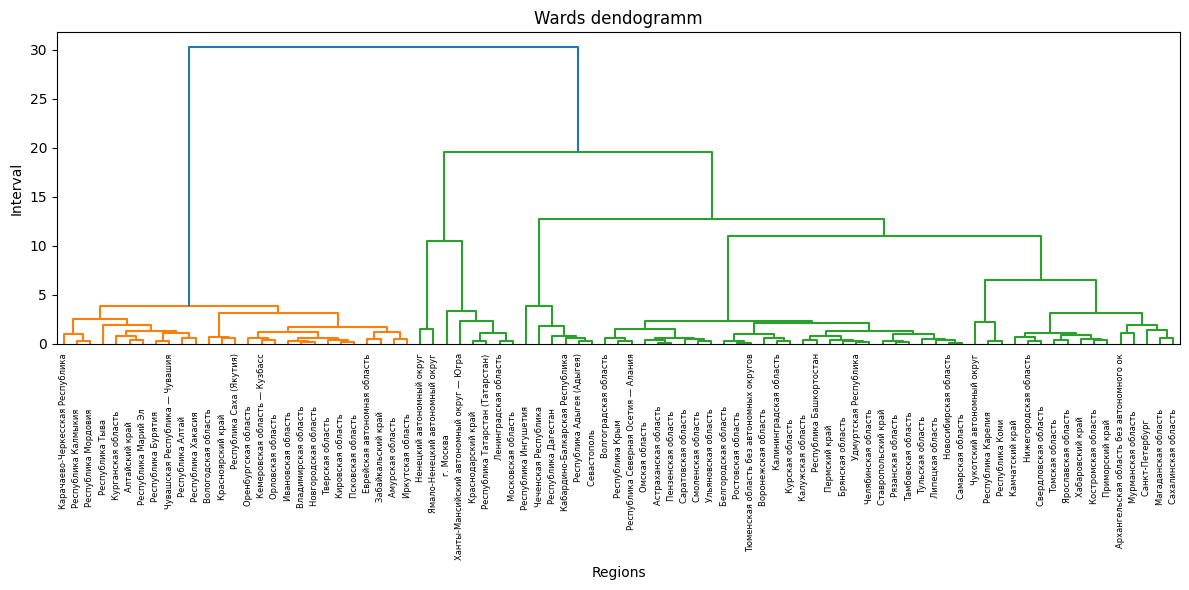

In [68]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
Z = linkage(result, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=result.index, orientation='top', leaf_rotation=90)
plt.title('Wards dendogramm')
plt.xlabel('Regions')
plt.ylabel('Interval')
plt.tight_layout()
plt.show()

In [58]:
def ward_clustering(n_clusters):
    clusters_ward = fcluster(Z, n_clusters, criterion='maxclust')
    result[f'Кластер_Уорд_{n_clusters}'] = clusters_ward

    print(f"\nКЛАСТЕРИЗАЦИЯ МЕТОДОМ УОРДА ({n_clusters} КЛАСТЕРОВ):")

    for cluster_num in range(1, n_clusters + 1):
        cluster_regions = result[result[f'Кластер_Уорд_{n_clusters}'] == cluster_num].index.tolist()
        print(f"\nКластер {cluster_num} ({len(cluster_regions)} регионов):")
        print(", ".join(cluster_regions))
    return clusters_ward
n_clusters_list = [7]
for n_clusters in n_clusters_list:
    ward_clustering(n_clusters)

7

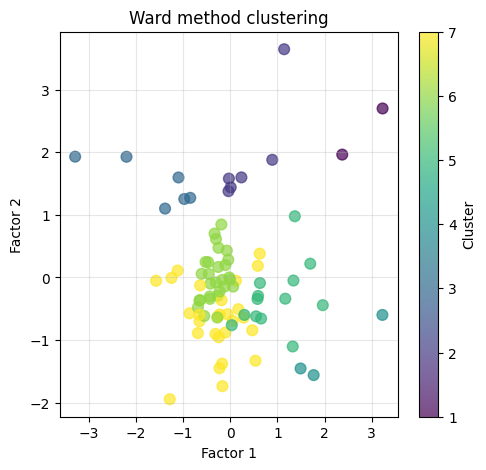

In [69]:
if num_components >= 2:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(result['Factor1'], result['Factor2'],
                         c=result['Кластер_Уорд_7'],
                         cmap='viridis', s=60, alpha=0.7)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('Factor 1')
    plt.ylabel('Factor 2')
    plt.title('Ward method clustering')
    plt.grid(True, alpha=0.3)

In [57]:
from sklearn.cluster import KMeans
def elbow_method(data, max_k=10):
    wcss = []  # Within-Cluster Sum of Square

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    return wcss

max_k = min(10, len(result) - 1)
wcss = elbow_method(result, max_k)
kmeans_7 = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels_7 = kmeans_7.fit_predict(result)
result['Кластер_Kmeans_7'] = kmeans_labels_7 + 1  # +1 чтобы кластеры начинались с 1

for cluster_num in range(1, 8):
    cluster_regions = result[result['Кластер_Kmeans_7'] == cluster_num].index.tolist()
    print(f"\nКластер {cluster_num} ({len(cluster_regions)} регионов):")
    print(", ".join(cluster_regions))


Кластер 1 (27 регионов):
Алтайский край                          , Амурская область                        , Владимирская область                    , Вологодская область                     , Еврейская автономная область, Забайкальский край                      , Ивановская область                      , Иркутская область                       , Карачаево-Черкесская Республика, Кемеровская область — Кузбасс, Кировская область                       , Красноярский край                       , Курганская область                      , Новгородская область                    , Оренбургская область                    , Орловская область                       , Псковская область                       , Республика Алтай                        , Республика Бурятия                      , Республика Калмыкия                     , Республика Марий Эл                     , Республика Мордовия                     , Республика Саха (Якутия), Республика Тыва                         , Республика Хак

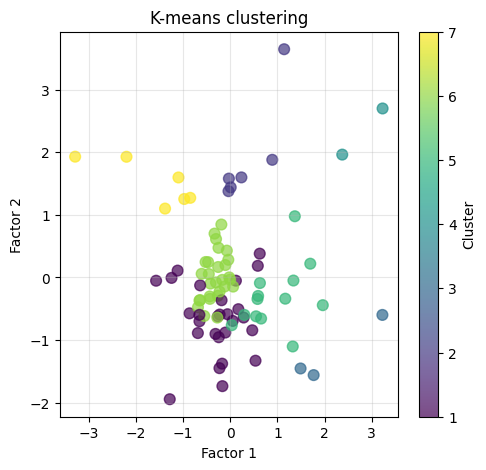

In [70]:
# Визуализация кластеров K-средних
if num_components >= 2:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(result['Factor1'], result['Factor2'],
                         c=result['Кластер_Kmeans_7'],
                         cmap='viridis', s=60, alpha=0.7)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('Factor 1')
    plt.ylabel('Factor 2')
    plt.title('K-means clustering')
    plt.grid(True, alpha=0.3)  # Добавление сетки с прозрачностью

In [60]:
import statsmodels.api as sm
file_path = 'питон 3.xlsx'
df = pd.read_excel(file_path)

In [61]:
X = df.iloc[:, 1:-1]  # Независимые переменные (F1 - Fm)
y = df.iloc[:, -1]     # Зависимая переменная (Y)
X_const = sm.add_constant(X)
model_initial = sm.OLS(y, X_const).fit()
print(model_initial.summary())

                            OLS Regression Results                            
Dep. Variable:                     X9   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                     5.902
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           7.22e-06
Time:                        13:56:06   Log-Likelihood:                -99.572
No. Observations:                  85   AIC:                             217.1
Df Residuals:                      76   BIC:                             239.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.151e-17      0.090  -3.52e-16      1.0

In [62]:
def create_results_table(model):
    results = pd.DataFrame({
        'Коэффициенты': model.params,
        'Стандартные ошибки': model.bse,
        't-статистика': model.tvalues,
        'p-значения': model.pvalues
    })
    return results
results_factors = create_results_table(model_initial)
print("\nТаблица результатов модели с факторами:\n", results_factors)


Таблица результатов модели с факторами:
        Коэффициенты  Стандартные ошибки  t-статистика  p-значения
const -3.151433e-17            0.089558 -3.518882e-16    1.000000
X1     6.250473e-02            0.123356  5.067006e-01    0.613832
X2    -6.573346e-01            0.192372 -3.417005e+00    0.001020
X3     6.999809e-01            0.172385  4.060567e+00    0.000118
X4     8.429163e-02            0.138183  6.100021e-01    0.543680
X5     4.195936e-01            0.114082  3.677993e+00    0.000436
X6    -1.437747e-01            0.133145 -1.079834e+00    0.283631
X7     2.573795e-03            0.132354  1.944625e-02    0.984536
X8     2.276118e-01            0.095611  2.380614e+00    0.019790


In [63]:
def create_regression_equation_formatted(model):
    coefs = model.params
    equation = f"Y = {coefs['const']:.4f}"
    for factor, coef in coefs.items():
        if factor != 'const':
            if coef >= 0:
                equation += f" + {coef:.4f}*{factor}"
            else:
                equation += f" - {abs(coef):.4f}*{factor}"
    return equation
regression_eq = create_regression_equation_formatted(model_initial)
print("Уравнение регрессии:")
print(regression_eq)

Уравнение регрессии:
Y = -0.0000 + 0.0625*X1 - 0.6573*X2 + 0.7000*X3 + 0.0843*X4 + 0.4196*X5 - 0.1438*X6 + 0.0026*X7 + 0.2276*X8


In [64]:
results_factors = results_factors[results_factors.index != 'const']
for factor in results_factors.index:
    coefficient = results_factors.loc[factor, 'Коэффициенты']
    if coefficient > 0:
        print(f"При увеличении «{factor}» на 1 единицу Y увеличится на {coefficient:.3f}.")
    else:
        print(f"При увеличении «{factor}» на 1 единицу Y уменьшится на {abs(coefficient):.3f}.")

При увеличении «X1» на 1 единицу Y увеличится на 0.063.
При увеличении «X2» на 1 единицу Y уменьшится на 0.657.
При увеличении «X3» на 1 единицу Y увеличится на 0.700.
При увеличении «X4» на 1 единицу Y увеличится на 0.084.
При увеличении «X5» на 1 единицу Y увеличится на 0.420.
При увеличении «X6» на 1 единицу Y уменьшится на 0.144.
При увеличении «X7» на 1 единицу Y увеличится на 0.003.
При увеличении «X8» на 1 единицу Y увеличится на 0.228.
